Author: Malcolm Zartman

Sharable Link: https://colab.research.google.com/drive/1Z132h04yboikbX25LB4EYSR43RU0Kl--?usp=sharing


In [ ]:
import nltk
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import *
nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
import string
import gensim
from gensim.models.phrases import Phraser, Phrases
from gensim.models.word2vec import Word2Vec
from sklearn.manifold import TSNE
import pandas as pd
from bokeh.io import output_notebook, output_file
from bokeh.plotting import show, figure

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
from nltk.corpus import gutenberg
len(gutenberg.fileids())
gutenberg.fileids()
len(gutenberg.words())
gberg_sent_tokens = sent_tokenize(gutenberg.raw())
gberg_sent_tokens[0:6]
gberg_sent_tokens[1]
word_tokenize(gberg_sent_tokens[1])
word_tokenize(gberg_sent_tokens[1])[14]
gberg_sents = gutenberg.sents()
gberg_sents[0:6]
gberg_sents[4][14]
gberg_sents[14]
[w.lower() for w in gberg_sents[4]]
stpwrds = stopwords.words('english') + list(string.punctuation)

In [ ]:
stpwrds

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
[w.lower() for w in gberg_sents[4] if w.lower() not in stpwrds]
stemmer = PorterStemmer()
[stemmer.stem(w.lower()) for w in gberg_sents[4]
if w.lower() not in stpwrds]
phrases = Phrases(gberg_sents)
bigram = Phraser(phrases)
bigram.phrasegrams
tokenized_sentence = 'Jon lives in New York City'.split()

In [ ]:
tokenized_sentence

['Jon', 'lives', 'in', 'New', 'York', 'City']

In [ ]:
bigram[tokenized_sentence]

['Jon', 'lives', 'in', 'New_York', 'City']

In [ ]:
lower_sents = []
for s in gberg_sents:
    lower_sents.append([w.lower() for w in s if w.lower() not in list(string.punctuation)])

In [ ]:
lower_sents[0:5]

[['emma', 'by', 'jane', 'austen', '1816'],
 ['volume', 'i'],
 ['chapter', 'i'],
 ['emma',
  'woodhouse',
  'handsome',
  'clever',
  'and',
  'rich',
  'with',
  'a',
  'comfortable',
  'home',
  'and',
  'happy',
  'disposition',
  'seemed',
  'to',
  'unite',
  'some',
  'of',
  'the',
  'best',
  'blessings',
  'of',
  'existence',
  'and',
  'had',
  'lived',
  'nearly',
  'twenty',
  'one',
  'years',
  'in',
  'the',
  'world',
  'with',
  'very',
  'little',
  'to',
  'distress',
  'or',
  'vex',
  'her'],
 ['she',
  'was',
  'the',
  'youngest',
  'of',
  'the',
  'two',
  'daughters',
  'of',
  'a',
  'most',
  'affectionate',
  'indulgent',
  'father',
  'and',
  'had',
  'in',
  'consequence',
  'of',
  'her',
  'sister',
  's',
  'marriage',
  'been',
  'mistress',
  'of',
  'his',
  'house',
  'from',
  'a',
  'very',
  'early',
  'period']]

In [ ]:
lower_bigram = Phraser(Phrases(lower_sents))
lower_bigram.phrasegrams

{'two_daughters': 11.080802900992637,
 'her_sister': 16.93971298099339,
 'very_early': 10.516998773665177,
 'her_mother': 10.70812618607742,
 'long_ago': 59.22644201533601,
 'more_than': 28.529926612065935,
 'had_been': 21.583193129694834,
 'an_excellent': 37.41859680854167,
 'sixteen_years': 131.42913000977518,
 'miss_taylor': 420.4340982546865,
 'mr_woodhouse': 104.19907841850323,
 'very_fond': 24.185726346489627,
 'passed_away': 11.751473221742694,
 'too_much': 30.363090173835406,
 'did_not': 10.846196223896685,
 'any_means': 14.294148100212627,
 'after_dinner': 18.60737125272944,
 'mr_weston': 91.63290824201266,
 'five_years': 37.66428596665674,
 'years_old': 48.59909444619029,
 'seven_years': 50.3345604292756,
 'each_other': 71.31277029783762,
 'well_informed': 14.185028016786626,
 'a_mile': 11.700110753652233,
 'difference_between': 207.86784241868986,
 'mrs_weston': 180.6778969011602,
 'could_not': 10.213333164207082,
 'having_been': 10.723750443105281,
 'sixteen_miles': 105.040

In [ ]:
lower_bigram['jon lives in new york city'.split()]

['jon', 'lives', 'in', 'new_york', 'city']

In [ ]:
lower_bigram = Phraser(Phrases(lower_sents, min_count=32, threshold=64))
lower_bigram.phrasegrams

{'miss_taylor': 156.44059469941823,
 'mr_woodhouse': 82.04651843976633,
 'mr_weston': 75.87438262077481,
 'mrs_weston': 160.6848509325892,
 'great_deal': 93.36368125424357,
 'mr_knightley': 161.74131790625913,
 'miss_woodhouse': 229.03802722366902,
 'years_ago': 74.31594785893046,
 'mr_elton': 121.3990121932397,
 'dare_say': 89.94000515807346,
 'frank_churchill': 1316.4456593286038,
 'miss_bates': 276.3958829169252,
 'drawing_room': 84.91494947493561,
 'mrs_goddard': 143.57843432545658,
 'miss_smith': 73.03442128232508,
 'few_minutes': 204.16834974753786,
 'john_knightley': 83.03755747111268,
 'don_t': 250.30957446808512,
 'good_natured': 88.69936184891343,
 'few_moments': 107.77584531675087,
 'thousand_pounds': 166.51834523092802,
 'o_clock': 89.14789088153574,
 'jane_fairfax': 654.556591758761,
 'miss_fairfax': 196.19987447261062,
 'ma_am': 157.25846601094193,
 'mrs_elton': 93.08931456265867,
 'forty_years': 90.60220877269607,
 'cut_off': 129.60290535032792,
 'ten_thousand': 84.00099

In [ ]:
clean_sents = []
for s in lower_sents:
    clean_sents.append(lower_bigram[s])

In [ ]:
clean_sents[0:9]

[['emma', 'by', 'jane', 'austen', '1816'],
 ['volume', 'i'],
 ['chapter', 'i'],
 ['emma',
  'woodhouse',
  'handsome',
  'clever',
  'and',
  'rich',
  'with',
  'a',
  'comfortable',
  'home',
  'and',
  'happy',
  'disposition',
  'seemed',
  'to',
  'unite',
  'some',
  'of',
  'the',
  'best',
  'blessings',
  'of',
  'existence',
  'and',
  'had',
  'lived',
  'nearly',
  'twenty',
  'one',
  'years',
  'in',
  'the',
  'world',
  'with',
  'very',
  'little',
  'to',
  'distress',
  'or',
  'vex',
  'her'],
 ['she',
  'was',
  'the',
  'youngest',
  'of',
  'the',
  'two',
  'daughters',
  'of',
  'a',
  'most',
  'affectionate',
  'indulgent',
  'father',
  'and',
  'had',
  'in',
  'consequence',
  'of',
  'her',
  'sister',
  's',
  'marriage',
  'been',
  'mistress',
  'of',
  'his',
  'house',
  'from',
  'a',
  'very',
  'early',
  'period'],
 ['her',
  'mother',
  'had',
  'died',
  'too',
  'long',
  'ago',
  'for',
  'her',
  'to',
  'have',
  'more',
  'than',
  'an',
 

In [ ]:
clean_sents[6]

['sixteen',
 'years',
 'had',
 'miss_taylor',
 'been',
 'in',
 'mr_woodhouse',
 's',
 'family',
 'less',
 'as',
 'a',
 'governess',
 'than',
 'a',
 'friend',
 'very',
 'fond',
 'of',
 'both',
 'daughters',
 'but',
 'particularly',
 'of',
 'emma']

In [ ]:
model = Word2Vec(sentences=clean_sents, vector_size=64, sg=1, window=10, epochs=5, min_count=10, workers=4)
model.save('clean_gutenberg_model.w2v')
model = gensim.models.Word2Vec.load('clean_gutenberg_model.w2v')
len(model.wv.key_to_index)

10329

In [ ]:
model.wv['dog']
len(model.wv['dog'])
model.wv.most_similar('dog',topn=3)
model.wv.most_similar('eat',topn=3)
model.wv.most_similar('day',topn=3)
model.wv.most_similar('father',topn=3)
model.wv.most_similar('ma_am',topn=3)
model.wv.doesnt_match('mother father sister brother dog'.split())
model.wv.similarity('father','dog')
model.wv.most_similar(positive=['father','woman'], negative=['man'])
model.wv.most_similar(positive=['husband','woman'], negative=['man'])

[('wife', 0.7279525399208069),
 ('sister', 0.714827835559845),
 ('maid', 0.6848939061164856),
 ('daughter', 0.6665307283401489),
 ('conceived', 0.6628628373146057),
 ('mother', 0.651287317276001),
 ('child', 0.6494927406311035),
 ('elder', 0.6359829306602478),
 ('harlot', 0.6312803030014038),
 ('nurse', 0.6270465850830078)]

In [ ]:
tsne = TSNE(n_components=2, n_iter=1000)

In [ ]:
X_2d = tsne.fit_transform(model.wv[model.wv.key_to_index])
coords_df = pd.DataFrame(X_2d, columns=['x','y'])
coords_df['token'] = model.wv.index_to_key

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
coords_df.head()

,x,y,token
0,-17.058332,-32.315113,the
1,-17.182081,-32.481846,and
2,-16.913006,-32.543175,of
3,-17.705278,-32.430874,to
4,-18.067190,-30.933212,a


In [ ]:
coords_df.to_csv('clean_gutenberg_tsne.csv',index=False)
coords_df=pd.read_csv('clean_gutenberg_tsne.csv')

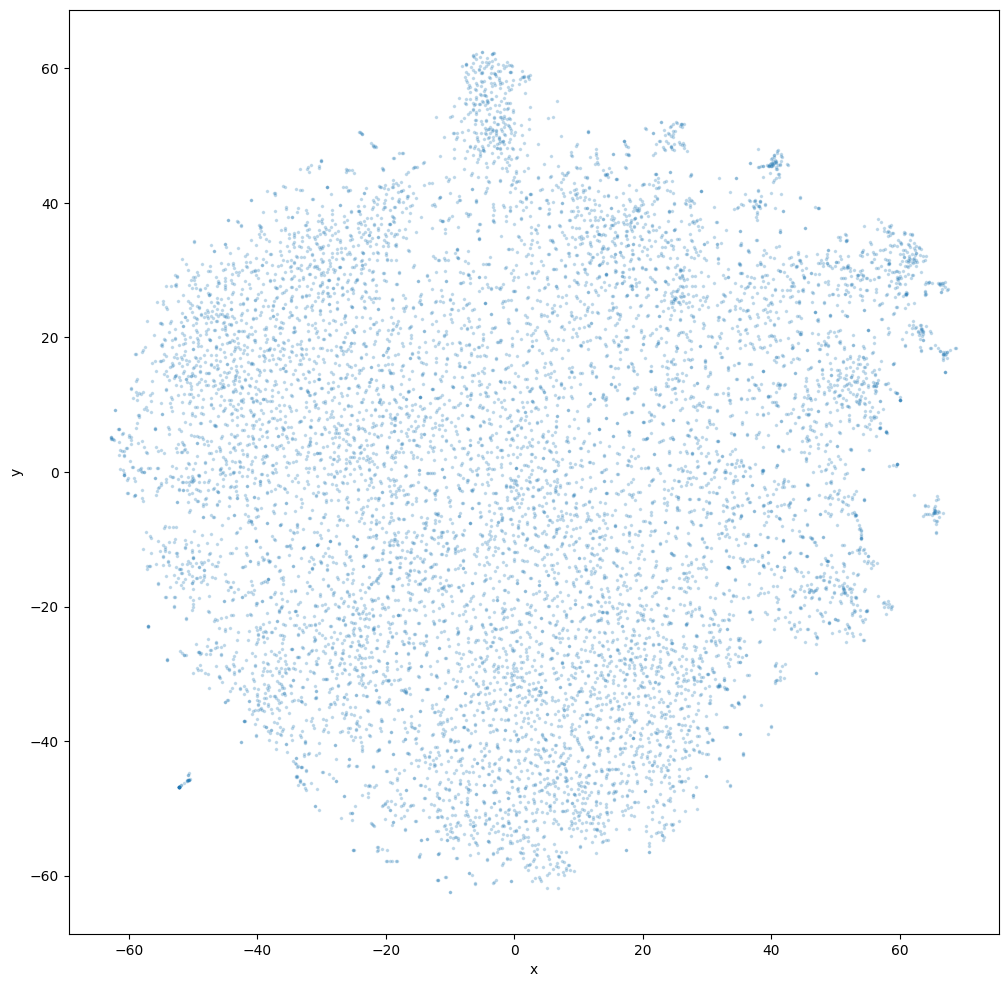

In [ ]:
_ = coords_df.plot.scatter('x','y',figsize=(12,12), marker='.', s=10, alpha=0.2)

In [ ]:
output_notebook()
subset_df = coords_df.sample(n=100)
p = figure(width=800, height=800)
_ = p.text(x=subset_df.x, y=subset_df.y, text=subset_df.token)

In [ ]:
show(p)